In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.tree import DecisionTreeClassifier


In [2]:
data = pd.read_csv('Automobile_data.csv')

In [3]:
data.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [4]:
data.replace('?', np.nan, inplace =True)
str_cols = data.select_dtypes(exclude = np.number)
num_cols = data.select_dtypes(include = np.number)

In [5]:
for i in num_cols:
    data[i]=pd.to_numeric(data[i], errors ='raise')
    data[i].fillna(data[i].median(), inplace = True)


In [6]:
for i in str_cols:
    data[i]= data[i].astype('category').cat.as_unordered()
    data[i].fillna(data[i].mode(), inplace = True)

In [7]:
for i in data:
    if(str(data[i].dtype) == 'category'):
        data[i]=data[i].cat.codes

In [8]:
X = data.drop('symboling', axis = 1)
y = data['symboling']
train_X,test_X,train_y,test_y = train_test_split(X,y,test_size =0.2)

              precision    recall  f1-score   support

          -1       0.50      0.33      0.40         3
           0       0.69      0.56      0.62        16
           1       0.56      0.91      0.69        11
           2       0.00      0.00      0.00         6
           3       0.33      0.20      0.25         5

    accuracy                           0.51        41
   macro avg       0.42      0.40      0.39        41
weighted avg       0.50      0.51      0.49        41

The F! Score using Logistic Regression --> 0.3920689655172414


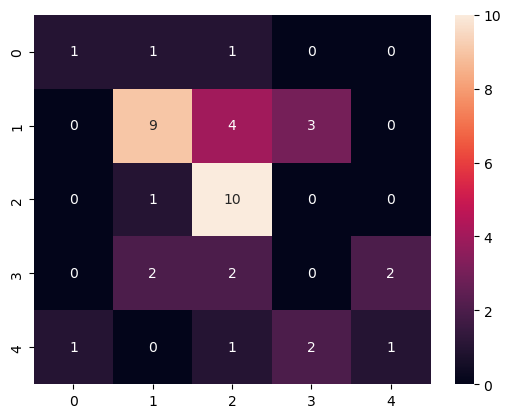

In [9]:
lr = LogisticRegression()
lr.fit(train_X,train_y)
y_pred = lr.predict(test_X)
print(classification_report(test_y, y_pred))
sns.heatmap(confusion_matrix(test_y, y_pred), annot = True)
print("The F! Score using Logistic Regression -->" , f1_score(test_y, y_pred, average='macro'))

              precision    recall  f1-score   support

          -1       1.00      0.33      0.50         3
           0       0.93      0.88      0.90        16
           1       0.79      1.00      0.88        11
           2       0.83      0.83      0.83         6
           3       1.00      1.00      1.00         5

    accuracy                           0.88        41
   macro avg       0.91      0.81      0.82        41
weighted avg       0.89      0.88      0.87        41

The F1 Score using Decision Tree  0.8233118279569893


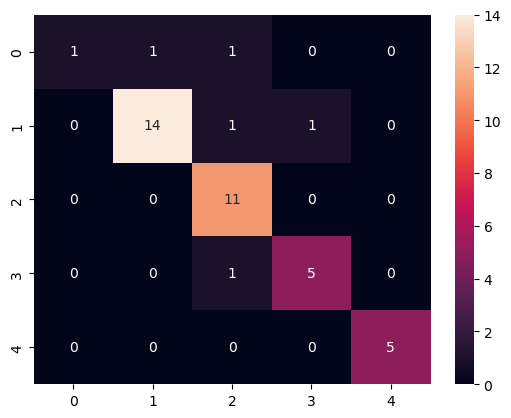

In [10]:
dr = DecisionTreeClassifier()
dr.fit(train_X,train_y)
dr_y_pred = dr.predict(test_X)
print(classification_report(test_y,dr_y_pred))
sns.heatmap(confusion_matrix(test_y,dr_y_pred), annot = True)
print("The F1 Score using Decision Tree ", f1_score(test_y,dr_y_pred, average ='macro'))

In [11]:
#Could not get this part to work properly --- ISSUE WITH GRAPHWIZ IMSTALLATION / IMPORT
#from sklearn.tree import export_graphviz
#import graphviz
#dot = export_graphviz(dr, out_file = None, feature_names = X.columns, class_names = True, filled = True, rounded = True)
#graph = graphviz.Source(dot)
#graph.render('dr', format ='png')
#graph

'''

HYPERPARAMETERS FOR TUNING MODEL 

criterion{“gini”, “entropy”, “log_loss”}, default=”

gini ”The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity and “log_loss” and “entropy” both for the Shannon information gain, see Mathematical formulation.

gini - faster, default, works great 90% entropy - sometimes for imbalanced data

splitter{“best”, “random”}, default=”best” The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.

BEST FINDS THE BEST SPLIT

max_depth int, default=None "How many questions can my tree ask?"

None - Max memorization 5 - Learns good patterns 2 - Very Simple, may underfit

min_samples_split int, default=2 "How many samples minimum should be present before I go on to ask the next question?" lower -> More Splits -> Overfitting higher -> fewer splits -> smoother tree / underfit

min_samples_leaf int: "How many samples end up in eachh of the final leaf / result group"

Small(1-2) -> Detailed Tree Bigger (5-20) -> Smoother tree / may underfit

max_features: help overfitting - Number of features / X variables to consider for each split

max_leaf_nodes int: Final number of leaves you want.. Fewer leaves - Simpler Lesser overfitting More leaves - More complex

ccp_alpha -> Post pruning parameter 0.0 - No pruning

0 - More pruning
'''

In [12]:
def sklearn_root_gini(X,y):
  result = []
  y = np.asarray(y)

  classes = np.unique(y)
  n_classes = len(classes)

  class_index = {cls:i for i,cls in enumerate(classes)}
  y_encoded = np.array([class_index[i] for i in y])

  for feature in X.columns:
    values = np.asarray(X[feature])
    order = np.argsort(values)
    values_sorted = values[order]
    y_sorted = y_encoded[order]
    #y_encoded = y_encoded[order]

    right_counts = np.bincount(y_encoded, minlength = n_classes).astype(float)
    left_counts = np.zeros(n_classes)

    best_gini = 1.0
    best_threshold = None

    for i in range(len(values_sorted) -1):
      cls = y_sorted[i]
      left_counts[cls]+=1
      right_counts[cls]-=1

      if values_sorted[i] == values_sorted[i+1]:
        continue

      threshold = (values_sorted[i] + values_sorted[i+1])/2
      left_total = i+1
      right_total = len(y_sorted)-left_total

      #Gini left
      p_left = left_counts/left_total
      g_left = 1.0-np.sum(p_left**2)

      #Gini right
      p_right = right_counts/right_total
      g_right = 1.0-np.sum(p_right**2)

      #weighted gini after split
      g_split = (left_total / len(y_sorted))*g_left + (right_total / len(y_sorted))*g_right

      if g_split < best_gini:
        best_gini= g_split
        best_threshold = threshold

      result.append((feature, best_gini, best_threshold))
  results = pd.DataFrame(result, columns = ['feature','gini','threshold'])
  return results.sort_values("gini")


In [13]:
results = sklearn_root_gini(train_X, train_y)
results.drop_duplicates()

,feature,gini,threshold
72,num-of-doors,0.675753,0.50
234,width,0.698889,64.30
108,wheel-base,0.702329,94.90
75,body-style,0.702953,2.50
204,width,0.703054,64.05
...,...,...,...
594,horsepower,0.774541,-0.50
651,peak-rpm,0.774541,-0.50
436,num-of-cylinders,0.775518,0.50
699,highway-mpg,0.775821,16.50


In [14]:
#IF splitting on this column does it make my data decision purer..
#importance = total impurity reduction contributed by the feature
#Importance(F) += (Impurity_parent - impurity_lef_child - impurity_right_child) x (samples_at_node / total_samples)
fi = pd.DataFrame({'Feature': X.columns, "Importance": dr.feature_importances_})
fi = fi.sort_values("Importance", ascending =False)

In [15]:
#Feature importance tells how much each feature contributed to reducing (Gini/Entropy)
#While building the tree
#could be used as feature selection technique like correlation
fi

,Feature,Importance
0,normalized-losses,0.154032
4,num-of-doors,0.131045
1,make,0.108117
8,wheel-base,0.105107
20,horsepower,0.082670
23,highway-mpg,0.074837
17,bore,0.068781
9,length,0.066524
11,height,0.063450
12,curb-weight,0.061924


In [16]:
# feature importance tells howmuch each feature contributed to reducing impurity (Gini / Entropy) while building the tree

# could also be used as feature selection technique like correlation

In [17]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

In [18]:
f1_macro = make_scorer(f1_score, average ='macro') # we are going f1 because of class imbalance


In [19]:
params = {
    'criterion': ['entropy'],
    'max_depth': [3,5,7,9,11, None],    
    'min_samples_split': [2,5,10,15],
    'min_samples_leaf': [1,2,4,6],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.5]
    }

In [20]:
grid = GridSearchCV(estimator = dr, param_grid = params, scoring = f1_macro, cv =5, n_jobs = -1, verbose =1)
grid.fit(train_X, train_y)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.0, 0.01, ...], 'criterion': ['entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,make_scorer(f...average=macro)
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [21]:
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [22]:
grid.best_score_

np.float64(0.7513290156695729)

In [23]:
params_1= {
    'criterion': ['gini'],
    'max_depth': [3,5,7,9,11, None],    
    'min_samples_split': [2,5,10,15],
    'min_samples_leaf': [1,2,4,6],
    'ccp_alpha': [0.0, 0.01, 0.1, 0.5]
    }

In [24]:
grid = GridSearchCV(estimator = dr, param_grid = params, scoring = f1_macro, cv =5, n_jobs = -1, verbose =1)
grid.fit(train_X, train_y)

Fitting 5 folds for each of 384 candidates, totalling 1920 fits


,estimator,DecisionTreeClassifier()
,param_grid,"{'ccp_alpha': [0.0, 0.01, ...], 'criterion': ['entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,make_scorer(f...average=macro)
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [25]:
print("Best parameters found: ", grid.best_params_)

Best parameters found:  {'ccp_alpha': 0.0, 'criterion': 'entropy', 'max_depth': 11, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [26]:
grid.best_score_

np.float64(0.7555678956979266)

In [27]:
'''
1. Data collection
2. EDA
3. Data pre-processing - Missing value - DT - Target missed means drop the row
4. Feature Selection - Correlation / DT feature Selection
5. Model building - Linear Regression / Tree / or whatever
6. Model Evaluation - CV
7. Model Hyper Parameter tuning
8. Default model / Tuned Model
9. Deploy the model
'''


'\n1. Data collection\n2. EDA\n3. Data pre-processing - Missing value - DT - Target missed means drop the row\n4. Feature Selection - Correlation / DT feature Selection\n5. Model building - Linear Regression / Tree / or whatever\n6. Model Evaluation - CV\n7. Model Hyper Parameter tuning\n8. Default model / Tuned Model\n9. Deploy the model\n'

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, f1_score

data = pd.read_csv('Automobile_data.csv')
data.replace('?', np.nan, inplace = True)
string_col = data.select_dtypes(exclude = np.number)
num_col = data.select_dtypes(include = np.number)


In [29]:
data['price'] = pd.to_numeric(data['price'], errors ='raise')


In [30]:
categorical_cols = data.select_dtypes(exclude = np.number).columns.tolist()

In [31]:
numeric_cols = data.select_dtypes(include =['float64', 'int64']).columns.tolist()

In [32]:
categorical_cols

['normalized-losses',
 'make',
 'fuel-type',
 'aspiration',
 'num-of-doors',
 'body-style',
 'drive-wheels',
 'engine-location',
 'engine-type',
 'num-of-cylinders',
 'fuel-system',
 'bore',
 'stroke',
 'horsepower',
 'peak-rpm']

In [33]:
numeric_cols

['symboling',
 'wheel-base',
 'length',
 'width',
 'height',
 'curb-weight',
 'engine-size',
 'compression-ratio',
 'city-mpg',
 'highway-mpg',
 'price']

In [34]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor
le_dict={}
for col in categorical_cols:
    le = LabelEncoder()
    print(" Before fit -- :", data[col])
    data[col] = le.fit_transform(data[col])
    print(" After fit -- :",data[col])
    le_dict[col]=le
    print("le_dict is --> :" , le_dict)
    

 Before fit -- : 0      NaN
1      NaN
2      NaN
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: object
 After fit -- : 0      51
1      51
2      51
3      27
4      27
       ..
200    49
201    49
202    49
203    49
204    49
Name: normalized-losses, Length: 205, dtype: int64
le_dict is --> : {'normalized-losses': LabelEncoder()}
 Before fit -- : 0      alfa-romero
1      alfa-romero
2      alfa-romero
3             audi
4             audi
          ...     
200          volvo
201          volvo
202          volvo
203          volvo
204          volvo
Name: make, Length: 205, dtype: object
 After fit -- : 0       0
1       0
2       0
3       1
4       1
       ..
200    21
201    21
202    21
203    21
204    21
Name: make, Length: 205, dtype: int64
le_dict is --> : {'normalized-losses': LabelEncoder(), 'make': LabelEncoder()}
 Before fit -- : 0         gas
1         gas
2         gas
3         g

In [35]:
data.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,51,0,1,0,1,0,2,0,88.6,...,130,5,23,4,9.0,5,10,21,27,13495.0
1,3,51,0,1,0,1,0,2,0,88.6,...,130,5,23,4,9.0,5,10,21,27,16500.0
2,1,51,0,1,0,1,2,2,0,94.5,...,152,5,1,27,9.0,20,10,19,26,16500.0
3,2,27,1,1,0,0,3,1,0,99.8,...,109,5,13,24,10.0,2,16,24,30,13950.0
4,2,27,1,1,0,0,3,0,0,99.4,...,136,5,13,24,8.0,8,16,18,22,17450.0


In [36]:
data.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                4
dtype: int64

In [37]:
#trying to impute using Decision Tree Regressor and Decision Tree Classifier
for col in data.columns:
    print(f'Processing column : {col} ')
    if data[col].isna().sum() > 0:
        print(f'INputting missiing values for column : {col} ')
        known = data[data[col].notna()]
        missing = data[data[col].isna()]
        print('Known data for imputation --> :', known)
        print('Missing data for imputation --> :', missing)

        X_train_imp = known.drop(col, axis = 1)
        y_train_imp = known[col]

        print('X_train_imp for imputation --> :', X_train_imp)

        print('y_train_imp for imputation --> :', y_train_imp)
        

        X_missing_imp = missing.drop(col, axis=1)
        print('X_missing_imp for imputation --> :', X_missing_imp)

        if col in numeric_cols: # impute using Decision Tree Regressor
            impute_model = DecisionTreeRegressor()
        else: # impute using Decision Tree Classifier
            impute_model = DecisionTreeClassifier()
        
        impute_model.fit(X_train_imp, y_train_imp)
        data.loc[data[col].isna(), col] = impute_model.predict(X_missing_imp)   
        print(f'Completed imputing missing values for column : {col} ')
        print("Data after imputing missing values --> :" , data[col])

Processing column : symboling 
Processing column : normalized-losses 
Processing column : make 
Processing column : fuel-type 
Processing column : aspiration 
Processing column : num-of-doors 
Processing column : body-style 
Processing column : drive-wheels 
Processing column : engine-location 
Processing column : wheel-base 
Processing column : length 
Processing column : width 
Processing column : height 
Processing column : curb-weight 
Processing column : engine-type 
Processing column : num-of-cylinders 
Processing column : engine-size 
Processing column : fuel-system 
Processing column : bore 
Processing column : stroke 
Processing column : compression-ratio 
Processing column : horsepower 
Processing column : peak-rpm 
Processing column : city-mpg 
Processing column : highway-mpg 
Processing column : price 
INputting missiing values for column : price 
Known data for imputation --> :      symboling  normalized-losses  make  fuel-type  aspiration  num-of-doors  \
0            3  

In [38]:
data.isna().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [39]:
X = data.drop('symboling', axis =1)
y = data['symboling']

x_train, x_test, y_train,y_test = train_test_split(X,y,test_size=0.2)

In [40]:
dt = DecisionTreeClassifier()
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [41]:
y_pred = dt.predict(x_test)

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

          -2       1.00      1.00      1.00         1
          -1       0.75      1.00      0.86         3
           0       0.75      0.90      0.82        10
           1       1.00      0.69      0.81        16
           2       1.00      1.00      1.00         3
           3       0.80      1.00      0.89         8

    accuracy                           0.85        41
   macro avg       0.88      0.93      0.90        41
weighted avg       0.88      0.85      0.85        41



<Axes: >

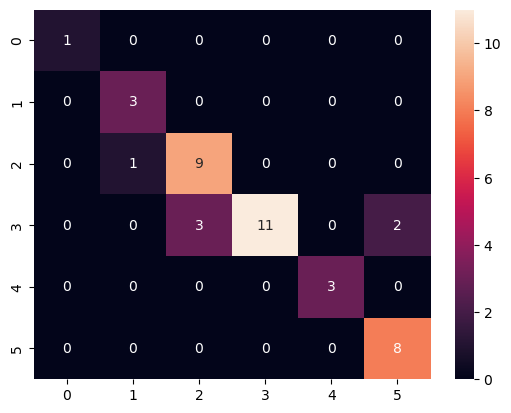

In [43]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot = True)

In [47]:
f1_score(y_test, y_pred, average ='macro')

0.8965047298380634